In [ ]:
!pip install pandas numpy matplotlib seaborn plotly scikit-learn openpyxl

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
from google.colab import files
import io

print("Please upload the Excel file when prompted.")
uploaded = files.upload()

excel_file_name = None
for name in uploaded.keys():
    if name.endswith('.xlsx') or name.endswith('.xls'):
        excel_file_name = name
        break

if excel_file_name:
    df = pd.read_excel(io.BytesIO(uploaded[excel_file_name]))
    print(f'Successfully loaded {excel_file_name} into DataFrame df.')
    display(df.head())
else:
    print("No Excel file found in uploaded files. Please ensure you've uploaded the correct Excel file.")

Please upload the Excel file when prompted.


Saving ApexPlanet_DataAnalytics_Dataset (1).xlsx to ApexPlanet_DataAnalytics_Dataset (1) (1).xlsx
Successfully loaded ApexPlanet_DataAnalytics_Dataset (1) (1).xlsx into DataFrame df.


,Order_ID,Order_Date,Customer_ID,Customer_Name,Age,Gender,City,Product,Category,Quantity,Unit_Price,Total_Sales
0,ORD100002,2025-02-25,CUST5529,Customer_227,30.0,Female,Bengaluru,Rice,Grocery,7,2829.77,19808.39
1,ORD100003,2025-10-14,CUST3127,Customer_182,63.0,Male,Bengaluru,Book,Education,5,27906.16,139530.80
2,ORD100004,2025-05-13,CUST8887,Customer_487,62.0,Female,Bengaluru,Book,Education,8,37491.06,299928.48
3,ORD100005,2025-12-02,CUST2515,Customer_470,65.0,Female,Kolkata,Mobile,Electronics,9,28541.36,256872.24
4,ORD100006,2025-11-20,CUST4796,Customer_380,44.0,Male,Bengaluru,Rice,Grocery,10,14036.59,140365.90


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order_ID       1000 non-null   object 
 1   Order_Date     1000 non-null   object 
 2   Customer_ID    1000 non-null   object 
 3   Customer_Name  1000 non-null   object 
 4   Age            980 non-null    float64
 5   Gender         1000 non-null   object 
 6   City           987 non-null    object 
 7   Product        1000 non-null   object 
 8   Category       1000 non-null   object 
 9   Quantity       1000 non-null   int64  
 10  Unit_Price     1000 non-null   float64
 11  Total_Sales    1000 non-null   float64
dtypes: float64(3), int64(1), object(8)
memory usage: 93.9+ KB


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Order_Date,0
Customer_ID,0
Customer_Name,0
Age,20
Gender,0
City,13
Product,0
Category,0
Quantity,0


In [ ]:
df.columns

Index(['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age',
       'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price',
       'Total_Sales', 'Year', 'Month'],
      dtype='object')

In [ ]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [ ]:
df["Year"] = df["Order_Date"].dt.year
df["Month"] = df["Order_Date"].dt.month_name()

In [ ]:
total_sales = df["Total_Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 139399439.65


In [ ]:
if "Profit" in df.columns:
    total_profit = df["Profit"].sum()
    print("Total Profit:", total_profit)
else:
    print("Column 'Profit' not found in DataFrame. Available columns are:", df.columns.tolist())

Column 'Profit' not found in DataFrame. Available columns are: ['Order_ID', 'Order_Date', 'Customer_ID', 'Customer_Name', 'Age', 'Gender', 'City', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Total_Sales', 'Year', 'Month']


In [ ]:
total_orders = df["Order_ID"].nunique()
print("Total Orders:", total_orders)

Total Orders: 992


In [ ]:
total_customers = df["Customer_ID"].nunique()
print("Total Customers:", total_customers)

Total Customers: 947


In [ ]:
aov = total_sales / total_orders

print("Average Order Value:", round(aov,2))

Average Order Value: 140523.63


In [ ]:
sales_category = df.groupby("Category")["Total_Sales"].sum()

print(sales_category)

Category
Education      25031689.40
Electronics    50778581.70
Fashion        19835895.79
Furniture      21521561.48
Grocery        22231711.28
Name: Total_Sales, dtype: float64


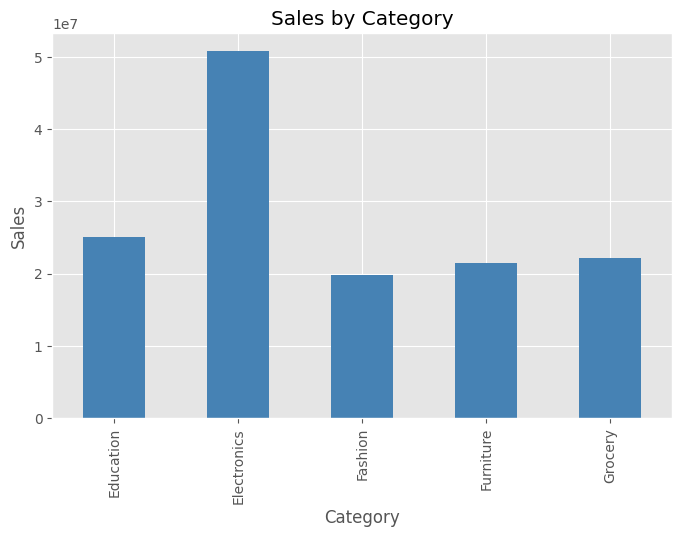

In [ ]:
sales_category.plot(kind="bar", figsize=(8,5), color="steelblue")

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

In [ ]:
if "Profit" in df.columns:
    profit_category = df.groupby("Category")["Profit"].sum()
    profit_category.plot(kind="bar", color="green")
    plt.title("Profit by Category")
    plt.show()
else:
    print("The 'Profit' column is not available in the DataFrame. Please consider if you need to calculate or create a 'Profit' column from existing data first.")

The 'Profit' column is not available in the DataFrame. Please consider if you need to calculate or create a 'Profit' column from existing data first.


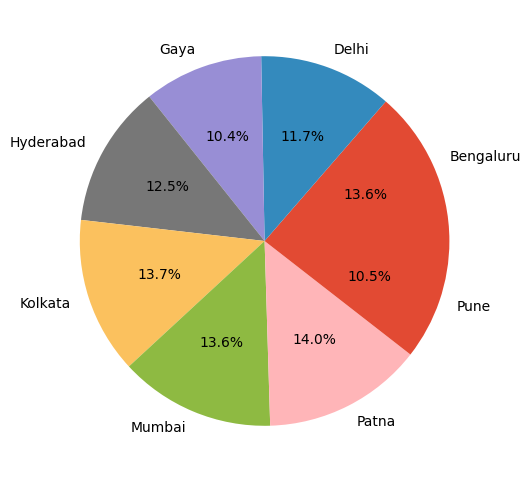

In [ ]:
sales_region = df.groupby("City")["Total_Sales"].sum()

sales_region.plot(kind="pie",
                  autopct="%1.1f%%",
                  figsize=(6,6))

plt.ylabel("")
plt.show()

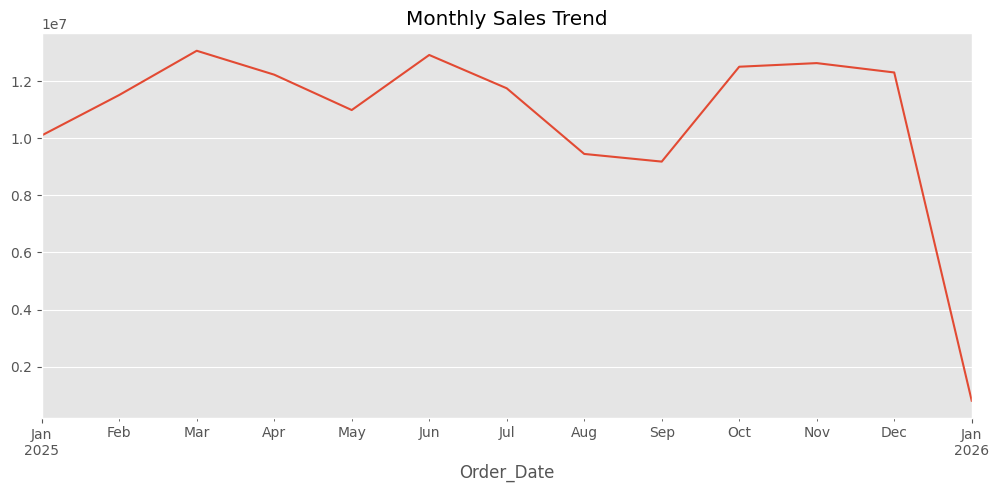

In [ ]:
monthly_sales = df.groupby(df["Order_Date"].dt.to_period("M"))["Total_Sales"].sum()

monthly_sales.plot(figsize=(12,5))

plt.title("Monthly Sales Trend")

plt.show()

In [ ]:
top_customers = df.groupby("Customer_Name")["Total_Sales"] \
                  .sum() \
                  .sort_values(ascending=False) \
                  .head(10)

print(top_customers)

Customer_Name
Customer_335    1684832.52
Customer_138    1305932.64
Customer_266    1269445.22
Customer_375    1196934.33
Customer_274    1060340.15
Customer_343    1025447.16
Customer_415     967962.17
Customer_355     954513.58
Customer_1       952753.99
Customer_359     941957.21
Name: Total_Sales, dtype: float64


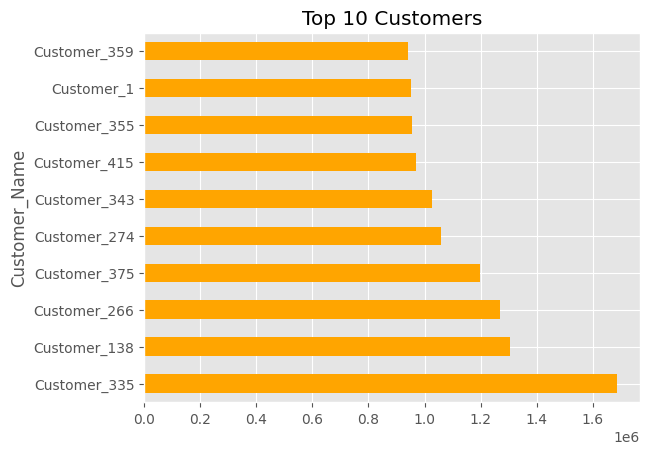

In [ ]:
top_customers.plot(kind="barh", color="orange")

plt.title("Top 10 Customers")

plt.show()

In [ ]:
customer_sales = df.groupby("Customer_Name")["Total_Sales"].sum().reset_index()

In [ ]:
def segment(x):

    if x >= 10000:
        return "High Value"

    elif x >= 5000:
        return "Medium Value"

    else:
        return "Low Value"

customer_sales["Segment"] = customer_sales["Total_Sales"].apply(segment)

In [ ]:
customer_sales.head()

,Customer_Name,Total_Sales,Segment
0,Customer_1,952753.99,High Value
1,Customer_10,786305.05,High Value
2,Customer_101,43532.50,High Value
3,Customer_102,265134.90,High Value
4,Customer_103,658671.63,High Value


In [ ]:
customer_sales["Segment"].value_counts()

,count
Segment,
High Value,416
Low Value,5
Medium Value,4


/tmp/ipykernel_519/609413750.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=customer_sales,


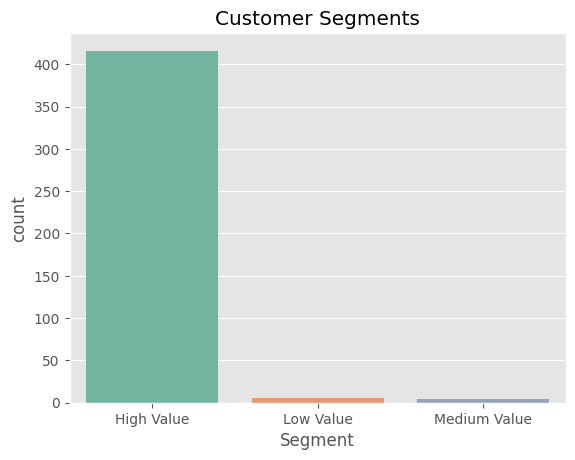

In [ ]:
sns.countplot(data=customer_sales,
              x="Segment",
              palette="Set2")

plt.title("Customer Segments")

plt.show()

In [ ]:
customer_sales.groupby("Segment")["Total_Sales"].mean()

,Total_Sales
Segment,
High Value,334998.787043
Low Value,2185.838000
Medium Value,7253.762500


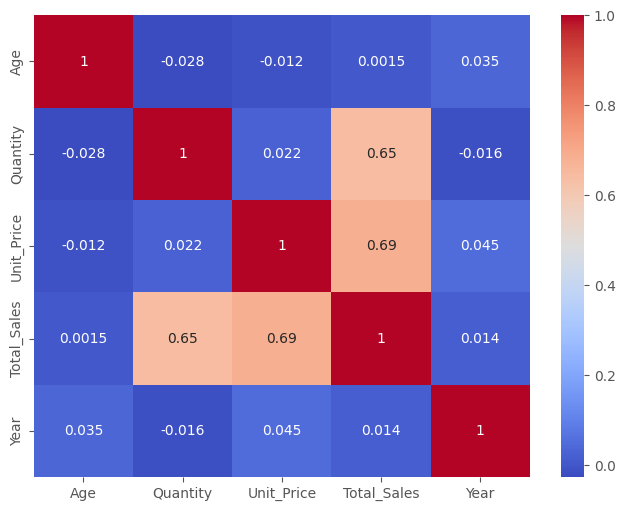

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

In [ ]:
customer_sales.to_csv("Customer_Segmentation.csv",
                      index=False)

In [ ]:
from google.colab import files

files.download("Customer_Segmentation.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>